## Cohort 분석
- 데이터 출처: https://dacon.io/competitions/official/236222/overview/description

In [7]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rc
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [8]:
!pip install pingouin
!pip install scipy
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

## 1. Load Data

In [9]:
df_sale = pd.read_csv('/content/drive/MyDrive/open/Onlinesales_info.csv')
df_cust = pd.read_csv('/content/drive/MyDrive/open/Customer_info.csv')
df_dis = pd.read_csv('/content/drive/MyDrive/open/Discount_info.csv')
df_mkt = pd.read_csv('/content/drive/MyDrive/open/Marketing_info.csv')
df_tax = pd.read_csv('/content/drive/MyDrive/open/Tax_info.csv')

### dataset info
- Onlinesales_info.csv [파일] 온라인거래와 관련된 정보
  - 고객ID : 고객 고유 ID
  - 거래ID : 거래 고유 ID
  - 거래날짜 : 거래가 이루어진 날짜
  - 제품ID : 제품 고유 ID
  - 제품카테고리 : 제품이 포함된 카테고리
  - 수량 : 주문한 품목 수
  - 평균금액 : 수량 1개당 가격 (단위 : 달러)
  - 동일 상품이어도 세부 옵션에 따라 가격이 다를 수 있음
  - 배송료 : 배송비용 (단위 : 달러)
  - 쿠폰상태 : 할인쿠폰 적용 상태

- Customer_info.csv [파일] 고객과 관련된 정보
  - 고객ID : 고객 고유 ID
  - 성별 : 고객 성별
  - 고객지역 : 고객지역
  - 가입기간 : 가입기간 (단위 : 월)

- Discount_info.csv [파일] 할인과 관련된 정보
  - 월 : 월(Month) 정보
  - 제품카테고리 : 제품이 포함된 카테고리
  - 쿠폰코드 : 쿠폰코드
  - 할인율 : 해당 쿠폰에 대한 할인율(%)

- Marketing_info.csv [파일] 마케팅비용과 관련된 정보
  - 날짜 : 마케팅이 이루어진 날짜
  - 오프라인비용 : 오프라인 마케팅으로 지출한 비용 (단위 : 달러)
  - 온라인비용 : 온라인 마케팅으로 지출한 비용 (단위 : 달러)

- Tax_info.csv [파일] 세금과 관련된 정보
  - 제품 카테고리 : 제품이 포함된 카테고리
  - GST : Goods and Services Tax(%)

## 2. Data Info

### 2-1. Data Info

In [10]:
df_sale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   고객ID    52924 non-null  object 
 1   거래ID    52924 non-null  object 
 2   거래날짜    52924 non-null  object 
 3   제품ID    52924 non-null  object 
 4   제품카테고리  52924 non-null  object 
 5   수량      52924 non-null  int64  
 6   평균금액    52924 non-null  float64
 7   배송료     52924 non-null  float64
 8   쿠폰상태    52924 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 3.6+ MB


In [11]:
df_cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1468 entries, 0 to 1467
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   고객ID    1468 non-null   object
 1   성별      1468 non-null   object
 2   고객지역    1468 non-null   object
 3   가입기간    1468 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 46.0+ KB


In [12]:
df_dis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   월       204 non-null    object
 1   제품카테고리  204 non-null    object
 2   쿠폰코드    204 non-null    object
 3   할인율     204 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 6.5+ KB


In [13]:
df_mkt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      365 non-null    object 
 1   오프라인비용  365 non-null    int64  
 2   온라인비용   365 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 8.7+ KB


In [14]:
df_tax.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   제품카테고리  20 non-null     object 
 1   GST     20 non-null     float64
dtypes: float64(1), object(1)
memory usage: 452.0+ bytes


In [15]:
df_sale['거래날짜'] = pd.to_datetime(df_sale['거래날짜'])
df_mkt['날짜'] = pd.to_datetime(df_mkt['날짜'])

### 2-2. 결측치 확인

In [16]:
print(df_sale.isnull().sum())
print('-'*15)
print(df_cust.isnull().sum())
print('-'*15)
print(df_dis.isnull().sum())
print('-'*15)
print(df_mkt.isnull().sum())
print('-'*15)
print(df_tax.isnull().sum())

고객ID      0
거래ID      0
거래날짜      0
제품ID      0
제품카테고리    0
수량        0
평균금액      0
배송료       0
쿠폰상태      0
dtype: int64
---------------
고객ID    0
성별      0
고객지역    0
가입기간    0
dtype: int64
---------------
월         0
제품카테고리    0
쿠폰코드      0
할인율       0
dtype: int64
---------------
날짜        0
오프라인비용    0
온라인비용     0
dtype: int64
---------------
제품카테고리    0
GST       0
dtype: int64


In [17]:
print(df_sale.shape)
print(df_cust.shape)
print(df_dis.shape)
print(df_mkt.shape)
print(df_tax.shape)

(52924, 9)
(1468, 4)
(204, 4)
(365, 3)
(20, 2)


### 2-3. Merge

### 2-3-1. merge(df_sale, df_cust)

In [18]:
df_sale['거래날짜'] = pd.to_datetime(df_sale['거래날짜'])
df_sale['월'] = df_sale['거래날짜'].dt.month

In [19]:
df_cust.shape[0], len(df_cust['고객ID'].unique())

(1468, 1468)

In [20]:
df = pd.merge(df_sale, df_cust, on='고객ID', how='left')

In [21]:
df.shape

(52924, 13)

### 2-3-2. merge(df, df_dis)

In [22]:
df_dis.shape

(204, 4)

In [23]:
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
    'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

df_dis['월'] = df_dis['월'].map(month_map)

In [24]:
df_dis['할인율'] = df_dis['할인율']/100

In [25]:
df_dis.head()

,월,제품카테고리,쿠폰코드,할인율
0,1,Apparel,SALE10,0.1
1,2,Apparel,SALE20,0.2
2,3,Apparel,SALE30,0.3
3,1,Nest-USA,ELEC10,0.1
4,2,Nest-USA,ELEC20,0.2


In [26]:
df = pd.merge(df, df_dis[['월', '제품카테고리', '할인율']],
              on=['월', '제품카테고리'], how='left')
df['할인율'] = df['할인율'].fillna(0)

In [27]:
df.shape

(52924, 14)

In [28]:
df['할인율'].isna().sum()

np.int64(0)

### 2-3-3. merge(df, df_mkt)

In [29]:
df_mkt.head()

,날짜,오프라인비용,온라인비용
0,2019-01-01,4500,2424.50
1,2019-01-02,4500,3480.36
2,2019-01-03,4500,1576.38
3,2019-01-04,4500,2928.55
4,2019-01-05,4500,4055.30


In [30]:
df = pd.merge(df, df_mkt, left_on='거래날짜', right_on='날짜', how='left')
df.drop(columns=['날짜'], inplace=True)


### 2-3-4. merge(df, df_tax)

In [31]:
df = pd.merge(df, df_tax, on='제품카테고리', how='left')

In [32]:
df.head()

,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,월,성별,고객지역,가입기간,할인율,오프라인비용,온라인비용,GST
0,USER_1358,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,1,남,Chicago,12,0.1,4500,2424.5,0.10
1,USER_1358,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,1,남,Chicago,12,0.1,4500,2424.5,0.10
2,USER_1358,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used,1,남,Chicago,12,0.1,4500,2424.5,0.10
3,USER_1358,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used,1,남,Chicago,12,0.1,4500,2424.5,0.18
4,USER_1358,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.5,Used,1,남,Chicago,12,0.1,4500,2424.5,0.18


### 2-4. 할인적용금액/세금적용금액/최종결제금액 컬럼 추가

In [33]:
df['쿠폰사용여부'] = df['쿠폰상태'].apply(lambda x: 1 if x == 'Used' else 0)

In [34]:
# 할인 적용
df['할인적용금액'] = df['평균금액'] * df['수량'] * (1 - (df['할인율'] * df['쿠폰사용여부']))

# 세금 추가 (배송료 미포함)
df['세금적용금액'] = df['할인적용금액'] * (1 + df['GST'])

# 최종 결제금액 (배송료 포함)
df['최종결제금액'] = df['세금적용금액'] + df['배송료']

In [35]:
df.head()

,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,월,...,고객지역,가입기간,할인율,오프라인비용,온라인비용,GST,쿠폰사용여부,할인적용금액,세금적용금액,최종결제금액
0,USER_1358,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,1,...,Chicago,12,0.1,4500,2424.5,0.10,1,138.339,152.1729,158.6729
1,USER_1358,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,1,...,Chicago,12,0.1,4500,2424.5,0.10,1,138.339,152.1729,158.6729
2,USER_1358,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used,1,...,Chicago,12,0.1,4500,2424.5,0.10,1,1.845,2.0295,8.5295
3,USER_1358,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used,1,...,Chicago,12,0.1,4500,2424.5,0.18,0,87.650,103.4270,109.9270
4,USER_1358,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.5,Used,1,...,Chicago,12,0.1,4500,2424.5,0.18,1,14.850,17.5230,24.0230


### 2-5. 첫구매일 컬럼 및 거래월 컬럼 생성

In [36]:
df['첫구매일'] = df.groupby('고객ID')['거래날짜'].transform('min')
df['코호트월'] = df['첫구매일'].dt.to_period('M')
df['거래월'] = df['거래날짜'].dt.to_period('M')
df['첫구매후거래월'] = (df['거래월'] - df['코호트월']).apply(lambda x: x.n)


In [37]:
df.isna().sum()

,0
고객ID,0
거래ID,0
거래날짜,0
제품ID,0
제품카테고리,0
수량,0
평균금액,0
배송료,0
쿠폰상태,0
월,0


In [38]:
df.shape

(52924, 25)

In [39]:
df.head()

,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,월,...,온라인비용,GST,쿠폰사용여부,할인적용금액,세금적용금액,최종결제금액,첫구매일,코호트월,거래월,첫구매후거래월
0,USER_1358,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,1,...,2424.5,0.10,1,138.339,152.1729,158.6729,2019-01-01,2019-01,2019-01,0
1,USER_1358,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,1,...,2424.5,0.10,1,138.339,152.1729,158.6729,2019-01-01,2019-01,2019-01,0
2,USER_1358,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used,1,...,2424.5,0.10,1,1.845,2.0295,8.5295,2019-01-01,2019-01,2019-01,0
3,USER_1358,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used,1,...,2424.5,0.18,0,87.650,103.4270,109.9270,2019-01-01,2019-01,2019-01,0
4,USER_1358,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.5,Used,1,...,2424.5,0.18,1,14.850,17.5230,24.0230,2019-01-01,2019-01,2019-01,0


## 3. cohort 분석

### 3-1. 첫구매후 거래월 합계

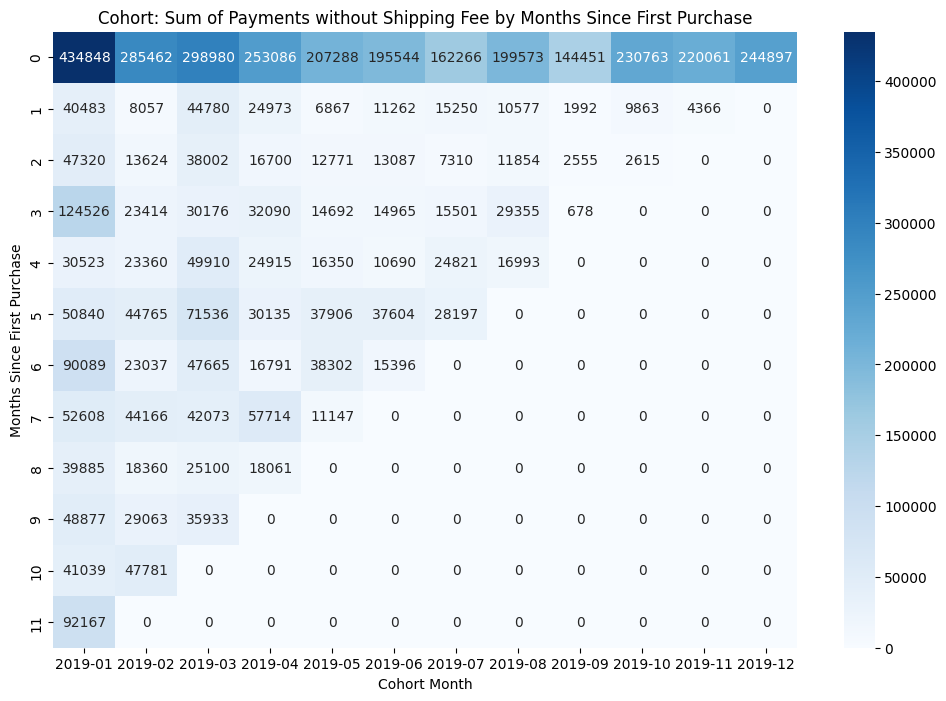

In [40]:
# 코호트별, 첫구매후거래월 합계(배송비 미포함) 집계
cohort_data = (
    df.groupby(['코호트월', '첫구매후거래월'])['세금적용금액']
      .sum()
      .unstack(level=0)
      .fillna(0)
)

# 시각화: 행=경과개월, 열=코호트월
plt.figure(figsize=(12, 8))
sns.heatmap(cohort_data, annot=True, fmt=".0f", cmap="Blues")
plt.xlabel('Cohort Month')
plt.ylabel('Months Since First Purchase')
plt.title('Cohort: Sum of Payments without Shipping Fee by Months Since First Purchase')
plt.show()

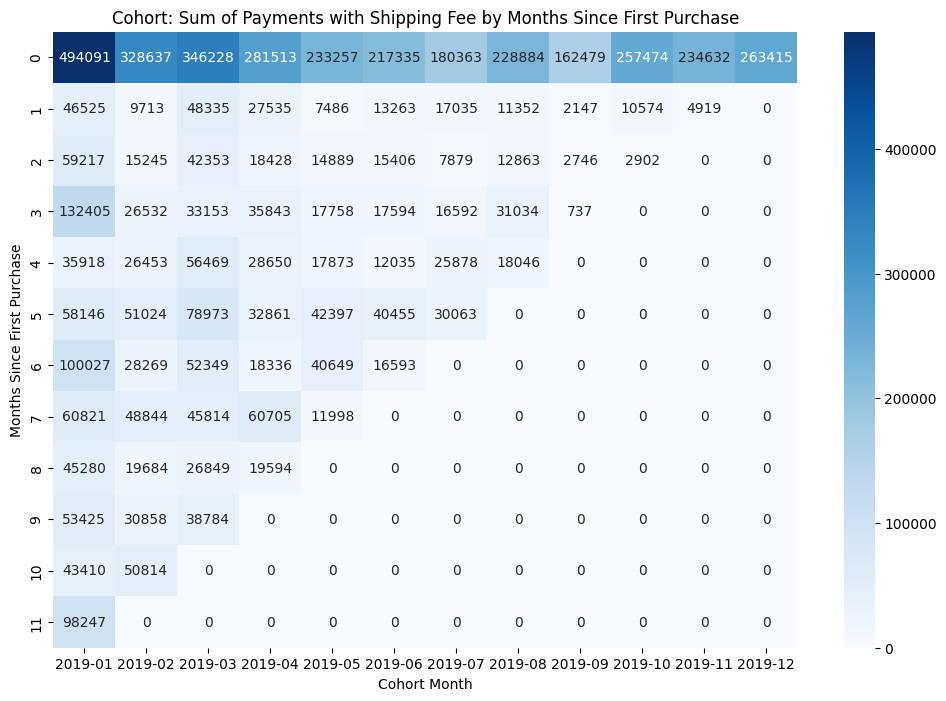

In [41]:
# 코호트별, 첫구매후거래월 합계(배송비 포함) 집계
cohort_data_with_fee = (
    df.groupby(['코호트월', '첫구매후거래월'])['최종결제금액']
      .sum()
      .unstack(level=0)
      .fillna(0)
)

# 시각화: 행=경과개월, 열=코호트월
plt.figure(figsize=(12, 8))
sns.heatmap(cohort_data_with_fee, annot=True, fmt=".0f", cmap="Blues")
plt.xlabel('Cohort Month')
plt.ylabel('Months Since First Purchase')
plt.title('Cohort: Sum of Payments with Shipping Fee by Months Since First Purchase')
plt.show()

- 배송비 미포함/포함이 동일한 패턴을 보이고 있음 (배송비 기여율 추후 분석)
- 초기 매출 대비 후속 매출 급락하는 패턴
- 코호트별 매출을 통해 고객수 감소인지 or 객단가 감소인지 분리



### 3-2. 코호트별 고객 수 및 ARPU 비교 (배송비 미포함)

In [42]:
cohort_metrics = (
    df.groupby(['코호트월', '첫구매후거래월'])
      .agg(
          고객수=('고객ID', 'nunique'),
          매출합계=('세금적용금액', 'sum')
      )
      .reset_index()
)

# 첫 달(첫구매후거래월 = 0)을 기준으로 각 코호트의 고객 수를 기록해두고, 이후 고객 수 대비 매출을 계산
first_month_customers = cohort_metrics[cohort_metrics['첫구매후거래월'] == 0]
first_month_customers = first_month_customers.set_index('코호트월')['고객수']

cohort_metrics['초기고객수'] = cohort_metrics['코호트월'].map(first_month_customers)
cohort_metrics['ARPU'] = cohort_metrics['매출합계'] / cohort_metrics['고객수']
cohort_metrics['고객수비율'] = cohort_metrics['고객수'] / cohort_metrics['초기고객수']
cohort_metrics['매출비율'] = cohort_metrics['매출합계'] / cohort_metrics.groupby('코호트월')['매출합계'].transform('first')
cohort_metrics['ARPU비율'] = cohort_metrics['ARPU'] / cohort_metrics.groupby('코호트월')['ARPU'].transform('first')

cohort_metrics.head()

,코호트월,첫구매후거래월,고객수,매출합계,초기고객수,ARPU,고객수비율,매출비율,ARPU비율
0,2019-01,0,215,434848.22875,215,2022.549901,1.000000,1.000000,1.000000
1,2019-01,1,13,40483.20322,215,3114.092555,0.060465,0.093097,1.539686
2,2019-01,2,24,47320.33012,215,1971.680422,0.111628,0.108820,0.974849
3,2019-01,3,34,124526.43909,215,3662.542326,0.158140,0.286368,1.810854
4,2019-01,4,23,30523.18904,215,1327.095176,0.106977,0.070193,0.656150


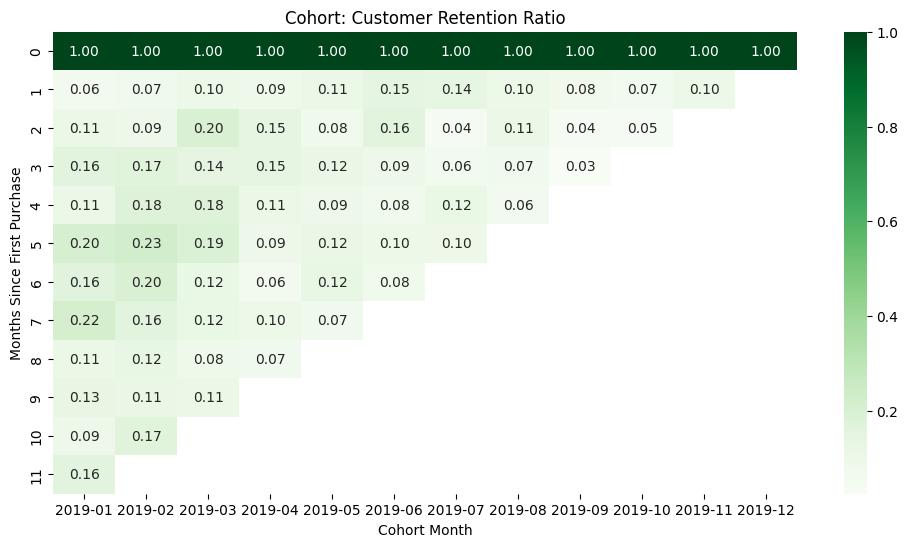

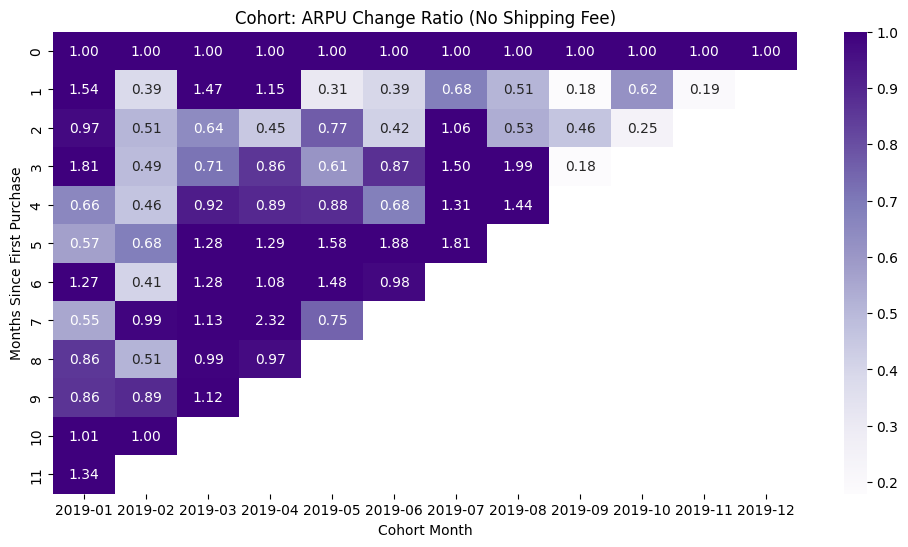

In [43]:
# 코호트별 고객 수 & ARPU 변화 시각화 예시
cohort_pivot_customers = cohort_metrics.pivot(index='첫구매후거래월', columns='코호트월', values='고객수비율')
cohort_pivot_arpu = cohort_metrics.pivot(index='첫구매후거래월', columns='코호트월', values='ARPU비율')

plt.figure(figsize=(12, 6))
sns.heatmap(cohort_pivot_customers, annot=True, fmt=".2f", cmap="Greens", vmax=1.0)
plt.title('Cohort: Customer Retention Ratio')
plt.xlabel('Cohort Month')
plt.ylabel('Months Since First Purchase')
plt.show()

plt.figure(figsize=(12, 6))
sns.heatmap(cohort_pivot_arpu, annot=True, fmt=".2f", cmap="Purples", vmax=1.0)
plt.title('Cohort: ARPU Change Ratio (No Shipping Fee)')
plt.xlabel('Cohort Month')
plt.ylabel('Months Since First Purchase')
plt.show()

- 첫 달 이후 고객수비율이 급락 (재구매 고객이 거의 없음)
- 반면 객단가는 오히려 상승 (=재구매 고객이 높은 금액을 지출)
- 매출 감소의 주된 요인은 빠른 고객 이탈로 보임

### 3-3. 조기 이탈 고객 속성 분석

In [44]:
# 고객별 마지막 거래 월(첫구매후거래월) 파악
customer_last = (
    df.groupby('고객ID')
      .agg(
          코호트월=('코호트월', 'first'),
          마지막경과월=('첫구매후거래월', 'max'),
          성별=('성별', 'first'),
          고객지역=('고객지역', 'first'),
          가입기간=('가입기간', 'first'),
          첫구매월=('거래월', 'min')
      )
      .reset_index()
)

# 1~2개월 내 이탈 고객 구분
early_churners = customer_last[customer_last['마지막경과월'] <= 1]

# 코호트별 조기 이탈 고객 비중 및 속성 분포
early_churn_summary = (
    early_churners
      .groupby('코호트월')
      .agg(
          조기이탈고객수=('고객ID', 'nunique'),
          평균가입기간=('가입기간', 'mean')
      )
      .reset_index()
)

# 2019-01 코호트 vs 기타 코호트 속성 비교용 피벗
attr_cols = ['성별', '고객지역']
attr_distribution = {}
for col in attr_cols:
    attr_distribution[col] = (
        early_churners
          .pivot_table(index=col, columns='코호트월', values='고객ID', aggfunc='nunique', fill_value=0)
          .assign(합계=lambda x: x.sum(axis=1))
    )

customer_last.head(), early_churn_summary.head(), attr_distribution['성별']

(        고객ID     코호트월  마지막경과월 성별        고객지역  가입기간     첫구매월
 0  USER_0000  2019-09       0  여    New York    31  2019-09
 1  USER_0001  2019-03       8  남    New York    20  2019-03
 2  USER_0002  2019-06       4  남  California    39  2019-06
 3  USER_0003  2019-12       0  남  California    25  2019-12
 4  USER_0004  2019-09       0  여     Chicago    31  2019-09,
       코호트월  조기이탈고객수     평균가입기간
 0  2019-01       98  27.030612
 1  2019-02       30  29.333333
 2  2019-03       77  27.285714
 3  2019-04       88  25.931818
 4  2019-05       63  25.031746,
 코호트월  2019-01  2019-02  2019-03  2019-04  2019-05  2019-06  2019-07  2019-08  \
 성별                                                                             
 남          35        8       26       32       21       31       27       39   
 여          63       22       51       56       42       56       43       68   
 
 코호트월  2019-09  2019-10  2019-11  2019-12   합계  
 성별                                             
 남          40  

- 가입기간이 충분히 긴 고객도 이탈하는 경우가 많으므로 첫 구매 이후 1~2개월 내 제공하는 혜택에 집중하여 초기 경험 개선 필요
- 조기 이탈 고객 중 여성 비중이 약 65%로 남성보다 크게 높음(여성 고객 경험 개선 필요)
- 고객지역을 확인해 지역별 편중 있는지 추가 검토 필요

### 3-3-1. 조기 이탈 고객(<=1개월) 거래 데이터 정리

In [45]:
# 조기 이탈 고객의 거래 내역만 추출 (첫구매후거래월 0~1)
early_churn_txn = df[
    (df['고객ID'].isin(early_churners['고객ID'])) &
    (df['첫구매후거래월'] <= 1)
].copy()

early_churn_txn['이탈코호트'] = early_churn_txn['코호트월'].astype(str)
early_churn_txn.head()

,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,월,...,GST,쿠폰사용여부,할인적용금액,세금적용금액,최종결제금액,첫구매일,코호트월,거래월,첫구매후거래월,이탈코호트
0,USER_1358,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,1,...,0.10,1,138.339,152.1729,158.6729,2019-01-01,2019-01,2019-01,0,2019-01
1,USER_1358,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,1,...,0.10,1,138.339,152.1729,158.6729,2019-01-01,2019-01,2019-01,0,2019-01
2,USER_1358,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used,1,...,0.10,1,1.845,2.0295,8.5295,2019-01-01,2019-01,2019-01,0,2019-01
3,USER_1358,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used,1,...,0.18,0,87.650,103.4270,109.9270,2019-01-01,2019-01,2019-01,0,2019-01
4,USER_1358,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.5,Used,1,...,0.18,1,14.850,17.5230,24.0230,2019-01-01,2019-01,2019-01,0,2019-01


### 3-3-2. 카테고리별/쿠폰상태별 조기 이탈 고객 비교

In [46]:
# 코호트 그룹 구분
early_churn_txn['코호트그룹'] = early_churn_txn['코호트월'].apply(
    lambda x: '2019-01' if x == pd.Period('2019-01', freq='M') else '기타'
)

# 제품 카테고리별 매출/고객 수 비교
category_compare = (
    early_churn_txn
      .groupby(['코호트그룹', '제품카테고리'])
      .agg(
          고객수=('고객ID', 'nunique'),
          거래건수=('거래ID', 'nunique'),
          매출합계=('세금적용금액', 'sum'),
          평균할인율=('할인율', 'mean')
      )
      .reset_index()
)

# 쿠폰 사용 비중 비교
coupon_compare = (
    early_churn_txn
      .groupby(['코호트그룹', '쿠폰상태'])
      .agg(
          고객수=('고객ID', 'nunique'),
          거래건수=('거래ID', 'nunique'),
          매출합계=('세금적용금액', 'sum')
      )
      .reset_index()
)

category_compare.head(), coupon_compare.head()

(     코호트그룹     제품카테고리  고객수  거래건수         매출합계     평균할인율
 0  2019-01    Android    2     2     38.56380  0.100000
 1  2019-01    Apparel   74   221  19961.10184  0.100458
 2  2019-01  Backpacks    1     1     90.77200  0.000000
 3  2019-01       Bags   34    63   6622.45028  0.100000
 4  2019-01    Bottles   11    11    460.71060  0.109091,
      코호트그룹      쿠폰상태  고객수  거래건수          매출합계
 0  2019-01   Clicked   92   692  123022.96470
 1  2019-01  Not Used   71   246   32574.46530
 2  2019-01      Used   87   503   67677.59507
 3       기타   Clicked  815  6332  977216.48330
 4       기타  Not Used  679  2536  295747.06070)

- Apparel, Bags, Beauty, Electronics 등 일부 카테고리에 이탈 고객이 집중
- 특히 Apparel의 비중이 높음
- 쿠폰 사용 측면 또한 Clicked와 Used 비중이 큼
- 의류/잡화 중심의 고객이 쿠폰을 사용했음에도 장기 유지를 못하고 빠르게 빠져나감

### 3-3-3. 지역별 조기 이탈 비율 계산

In [47]:
# 전체 고객 거래 데이터 기준 지역별 매출/고객수
region_total = (
    df.groupby('고객지역')
      .agg(
          전체고객수=('고객ID', 'nunique'),
          전체매출=('세금적용금액', 'sum')
      )
      .reset_index()
)

# 조기 이탈 고객 기준 지역별 매출/고객수
region_churn = (
    early_churn_txn.groupby('고객지역')
      .agg(
          이탈고객수=('고객ID', 'nunique'),
          이탈매출=('세금적용금액', 'sum')
      )
      .reset_index()
)

region_compare = (
    region_total.merge(region_churn, on='고객지역', how='left')
                 .fillna({'이탈고객수': 0, '이탈매출': 0})
)

region_compare['이탈고객비율'] = region_compare['이탈고객수'] / region_compare['전체고객수']
region_compare['이탈매출비율'] = region_compare['이탈매출'] / region_compare['전체매출']

region_compare.sort_values('이탈매출비율', ascending=False)

,고객지역,전체고객수,전체매출,이탈고객수,이탈매출,이탈고객비율,이탈매출비율
4,Washington DC,75,2.666718e+05,42,131244.97570,0.560000,0.492159
3,New York,324,9.700051e+05,209,444464.93328,0.645062,0.458209
2,New Jersey,149,4.249915e+05,97,175084.43316,0.651007,0.411972
0,California,464,1.495640e+06,309,599571.69255,0.665948,0.400880
1,Chicago,456,1.683415e+06,294,647345.09840,0.644737,0.384543


- California와 Chicago, New York, New Jersy의 이탈고객비율이 평균 65%로 매우 높음
- 해당 지역 고객의 제품 경험(배송 지연, 품질 불만, 반품 등) 점검 필요
- Washington DC처럼 고객 수는 적어도 매출이 높은 지역은 VIP 관리나 개인화 혜택 필요


### 3-3-4. 성별별 잔존율·이탈율 및 ARPU 비교

,성별,고객수,조기이탈고객수,조기이탈율,잔존율,총매출,ARPU
0,남,534,335,0.627341,0.372659,1.825472e+06,3418.486305
1,여,934,616,0.659529,0.340471,3.015252e+06,3228.321188


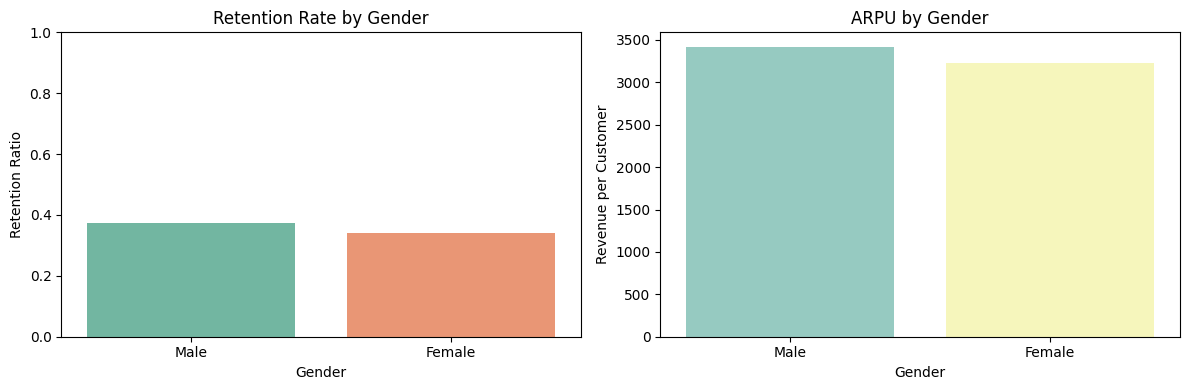

In [48]:
gender_churn = (
    customer_last
      .assign(조기이탈=lambda x: (x['마지막경과월'] <= 1).astype(int))
      .groupby('성별')
      .agg(
          고객수=('고객ID', 'nunique'),
          조기이탈고객수=('조기이탈', 'sum')
      )
      .assign(
          조기이탈율=lambda x: x['조기이탈고객수'] / x['고객수'],
          잔존율=lambda x: 1 - x['조기이탈율']
      )
      .reset_index()
)

gender_revenue = (
    df.groupby('성별')
      .agg(
          총매출=('세금적용금액', 'sum'),
          고객수=('고객ID', 'nunique')
      )
      .assign(ARPU=lambda x: x['총매출'] / x['고객수'])
      .reset_index()
)

# 성별 기준 핵심 지표 테이블
gender_summary = gender_churn.merge(
    gender_revenue[['성별', '총매출', 'ARPU']],
    on='성별',
    how='left'
)

display(gender_summary)

# 시각화: 잔존율과 ARPU 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

gender_summary['성별'] = gender_summary['성별'].map({'남': 'Male', '여': 'Female'})

sns.barplot(data=gender_summary, x='성별', y='잔존율', ax=axes[0], palette='Set2')
axes[0].set_ylim(0, 1)
axes[0].set_title('Retention Rate by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Retention Ratio')

sns.barplot(data=gender_summary, x='성별', y='ARPU', ax=axes[1], palette='Set3')
axes[1].set_title('ARPU by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Revenue per Customer')

plt.tight_layout()
plt.show()

- 잔존율과 평균매출(ARPU)는 남성이 여성에 비해 높지만
- 총 매출과 절대수로 보았을 대 여성의 비중의 남성의 약 2배임
- 여성 고객의 비중과 여성 고객 이탈 수가 모두 높은만큼 우선적인 분석이 요구됨

### 3-4. 여성 고객 이탈 분석

In [49]:
female_churn_txn = early_churn_txn[early_churn_txn['성별'] == '여']

female_category = (
    female_churn_txn
      .groupby(['코호트그룹', '제품카테고리'])
      .agg(
          여성고객수=('고객ID', 'nunique'),
          거래건수=('거래ID', 'nunique'),
          매출합계=('세금적용금액', 'sum'),
          평균할인율=('할인율', 'mean')
      )
      .reset_index()
)

female_coupon = (
    female_churn_txn
      .groupby(['코호트그룹', '쿠폰상태'])
      .agg(
          여성고객수=('고객ID', 'nunique'),
          거래건수=('거래ID', 'nunique'),
          매출합계=('세금적용금액', 'sum')
      )
      .reset_index()
)

female_category.head(), female_coupon.head()

(     코호트그룹     제품카테고리  여성고객수  거래건수         매출합계     평균할인율
 0  2019-01    Android      1     1     18.15000  0.100000
 1  2019-01    Apparel     48   112  10480.59598  0.100901
 2  2019-01       Bags     18    28   2168.47184  0.100000
 3  2019-01    Bottles      8     8    281.26770  0.112500
 4  2019-01  Drinkware     31    55   3635.45610  0.103529,
      코호트그룹      쿠폰상태  여성고객수  거래건수          매출합계
 0  2019-01   Clicked     59   329   55287.24790
 1  2019-01  Not Used     45   119   14843.73560
 2  2019-01      Used     54   236   28961.59981
 3       기타   Clicked    526  4001  631905.56440
 4       기타  Not Used    436  1602  188541.49470)

- 프로모션을 본/사용한 여성 고객이 초기에 이탈하는 패턴
- 할인과 노출된 프로모션이 이탈을 막지 못하고 있음
- 단순 할인이 아닌 추가적인 후속 커뮤니케이션 또는 맞춤형 프로모션 필요

### 3-4-1. 여성 고객 카테고리별 이탈 지표 계산

In [50]:
# 전체 여성 고객 기준 제품 카테고리 집계
female_total = (
    df[df['성별'] == '여']
      .groupby('제품카테고리')
      .agg(
          전체여성고객수=('고객ID', 'nunique'),
          전체여성매출=('세금적용금액', 'sum')
      )
      .reset_index()
)

# 조기 이탈 여성 고객 기준 집계
female_churn = (
    early_churn_txn[early_churn_txn['성별'] == '여']
      .groupby('제품카테고리')
      .agg(
          이탈여성고객수=('고객ID', 'nunique'),
          이탈여성매출=('세금적용금액', 'sum')
      )
      .reset_index()
)

female_category_compare = (
    female_total.merge(female_churn, on='제품카테고리', how='left')
                .fillna({'이탈여성고객수': 0, '이탈여성매출': 0})
)

female_category_compare['이탈여성고객비율'] = female_category_compare['이탈여성고객수'] / female_category_compare['전체여성고객수']
female_category_compare['이탈여성매출비율'] = female_category_compare['이탈여성매출'] / female_category_compare['전체여성매출']
female_category_compare['전체대비이탈여성고객비중'] = female_category_compare['이탈여성고객수'] / female_category_compare['이탈여성고객수'].sum()
female_category_compare['전체대비이탈여성매출비중'] = female_category_compare['이탈여성매출'] / female_category_compare['이탈여성매출'].sum()

female_category_compare.sort_values('이탈여성고객비율', ascending=False)

,제품카테고리,전체여성고객수,전체여성매출,이탈여성고객수,이탈여성매출,이탈여성고객비율,이탈여성매출비율,전체대비이탈여성고객비중,전체대비이탈여성매출비중
2,Apparel,837,4.174584e+05,523,159115.43266,0.624851,0.381153,0.172209,0.128991
16,Nest-USA,786,1.624977e+06,485,670593.45100,0.617048,0.412679,0.159697,0.543635
18,Office,699,1.806249e+05,415,82364.21930,0.593705,0.455996,0.136648,0.066771
6,Drinkware,578,1.386412e+05,320,49524.98114,0.553633,0.357217,0.105367,0.040149
12,Lifestyle,510,5.027761e+04,275,20496.64956,0.539216,0.407669,0.090550,0.016616
4,Bags,451,1.156929e+05,237,53302.16114,0.525499,0.460721,0.078038,0.043211
13,More Bags,27,2.961186e+03,14,1052.20600,0.518519,0.355333,0.004610,0.000853
14,Nest,330,3.016127e+05,167,133662.20175,0.506061,0.443158,0.054988,0.108357
10,Headgear,263,3.262648e+04,131,10208.28795,0.498099,0.312884,0.043135,0.008276
0,Accessories,95,4.946633e+03,47,1367.87750,0.494737,0.276527,0.015476,0.001109


### 3-4-2. 지역×여성×카테고리 조기 이탈 분석

In [51]:
# 대상 지역 목록
focus_regions = ['California', 'Chicago']

regional_female_churn = (
    early_churn_txn[
        (early_churn_txn['성별'] == '여') &
        (early_churn_txn['고객지역'].isin(focus_regions))
    ]
      .groupby(['고객지역', '제품카테고리'])
      .agg(
          여성고객수=('고객ID', 'nunique'),
          거래건수=('거래ID', 'nunique'),
          매출합계=('세금적용금액', 'sum'),
          평균할인율=('할인율', 'mean')
      )
      .reset_index()
)

# 전체 여성 고객 대비 해당 지역·카테고리의 이탈 비중 계산용
regional_female_total = (
    df[(df['성별'] == '여') & (df['고객지역'].isin(focus_regions))]
      .groupby(['고객지역', '제품카테고리'])
      .agg(
          전체여성고객수=('고객ID', 'nunique'),
          전체여성매출=('세금적용금액', 'sum')
      )
      .reset_index()
)

regional_female_compare = (
    regional_female_total.merge(regional_female_churn, on=['고객지역', '제품카테고리'], how='left')
                         .fillna({'여성고객수': 0, '거래건수': 0, '매출합계': 0, '평균할인율': 0})
)

regional_female_compare['이탈여성고객비율'] = (
    regional_female_compare['여성고객수'] / regional_female_compare['전체여성고객수']
)
regional_female_compare['이탈여성매출비율'] = (
    regional_female_compare['매출합계'] / regional_female_compare['전체여성매출']
)

regional_female_compare.sort_values(['고객지역', '이탈여성고객비율'], ascending=[True, False])

,고객지역,제품카테고리,전체여성고객수,전체여성매출,여성고객수,거래건수,매출합계,평균할인율,이탈여성고객비율,이탈여성매출비율
2,California,Apparel,266,122087.09048,167,652,44257.53548,0.206346,0.627820,0.362508
16,California,Nest-USA,247,493423.33810,152,988,219917.62870,0.198968,0.615385,0.445698
18,California,Office,227,55160.57580,134,299,25372.78810,0.197674,0.590308,0.459980
1,California,Android,7,129.09930,4,4,64.90330,0.200000,0.571429,0.502739
6,California,Drinkware,188,47058.80592,107,202,19457.69142,0.214386,0.569149,0.413476
12,California,Lifestyle,165,13495.87004,93,140,4334.24030,0.177637,0.563636,0.321153
13,California,More Bags,11,1982.97820,6,6,502.12540,0.000000,0.545455,0.253218
14,California,Nest,103,105734.61255,56,208,52503.97530,0.235897,0.543689,0.496564
4,California,Bags,142,36212.30138,77,123,16557.70926,0.203521,0.542254,0.457240
0,California,Accessories,32,3014.83380,17,24,414.83090,0.234615,0.531250,0.137597


#### 카테고리별:
- Apparel·NestUSA·Office 카테고리에서 California와 Chicago 모두 여성 고객의 이탈이 크게 집중
- 각 지역에서 전체 여성 고객 대비 이탈 고객 비율이 50~65% 수준으로 매우 높고(Apparel 0.63/0.60, Nest-USA 0.62/0.60)
- 이탈 여성 매출 비율도 0.35~0.45 이상, 실질적으로 여성 조기 이탈의 1순위 타깃

#### 지역별:
- California는 프리미엄 카테고리(Nest 계열, Nest-USA, Nest-Canada) 이탈 비중이 높음
- Chicago는 Drinkware·Lifestyle 같은 생활잡화에서도 높은 이탈률이 보임
- 지역별로 상품 구성이나 후속 혜택을 차별화할 필요가 있음

---

### 핵심 인사이트
- 모든 코호트에서 첫 달 이후 재구매율이 급감하며 여성 고객 비중이 전체의 약 64%를 차지.
- 여성 조기 이탈 고객이 남성 대비 두 배 수준이어서 여성 세그먼트에서의 매출 손실이 상대적으로 큼.
- California·Chicago 등 주요 지역의 패션·프리미엄 카테고리에서 여성 이탈이 집중 발생.

### 우선 실행 과제
- 1차로 여성 고객 대상 초기 경험 개선 프로그램(배송·품질·사용 안내) 설계.
- 이탈율이 높은 지역·카테고리(특히 Apparel·Nest 시리즈)에 대한 CS·배송 데이터 점검과 개선.
- 쿠폰 사용 이후 1개월 내 후기 요청, 맞춤 추천, 교환·반품 지원 등 후속 커뮤니케이션 자동화.

### 추가 분석 제안
- 리텐션 구간 세분화: 0~1개월, 2~3개월 등 단계별 행동·매출 차이 분석.